# **Importing Libraries**


In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import joblib

# **Required Preprocessing**


## Pre-1

In [5]:
COLUMNS = ["age", "sex", "cp", "trestbps", "chol", "fbs", "restecg", "thalach", "exang", "oldpeak", "slope", "ca", "thal", "target"]

df = pd.read_csv("processed.cleveland.data",header=None, names=COLUMNS)
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [13]:
print("Shape =", df.shape)
print("\nData Types =")
print(df.dtypes)

Shape = (303, 14)

Data Types =
age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca           object
thal         object
target        int64
dtype: object


## Pre-2

In [14]:
df.replace("?", np.nan, inplace=True)

# Convert all columns to numeric (some may have been read as object due to '?')
df = df.apply(pd.to_numeric, errors="coerce")

missing = df.isnull().sum()
missing_cols = missing[missing > 0]

print("Columns with missing values (after replacing '?'):")
print(missing_cols)
df.dropna(inplace=True)
print(f"\nFinal retained rows after dropping NaN: {len(df)}")

Columns with missing values (after replacing '?'):
ca      4
thal    2
dtype: int64

Final retained rows after dropping NaN: 297


## Pre-3

In [18]:
df["target"] = (df["target"] > 0).astype(int)

counts = df["target"].value_counts().sort_index()
pct    = df["target"].value_counts(normalize=True).sort_index() * 100
dist   = pd.DataFrame({"count": counts, "%": pct.round(1)})

print("Class Distribution")
print(dist.to_markdown())

ratio = counts[0] / counts[1]
print(f"\nClass ratio (0:1) = {ratio:.2f}")

Class Distribution
|   target |   count |    % |
|---------:|--------:|-----:|
|        0 |     160 | 53.9 |
|        1 |     137 | 46.1 |

Class ratio (0:1) = 1.17


The dataset is well-balanced (54%-46%) so SMOTE is not needed. No resampling will be applied. Downstream classifiers can optionally use class_weight='balanced' as a minor safeguard, but it is not required.

## Pre-4

In [19]:
categorical_columns = ["cp", "restecg", "slope", "thal"]
continuous_columns  = ["age", "trestbps", "chol", "thalach", "oldpeak", "ca"]

print("Encoding & Scaling (definitions)")
print(f"Categorical columns one-hot encodeing : {categorical_columns}")
print(f"Continuous columns standardization    : {continuous_columns}")

X_raw = df.drop(columns="target")
y     = df["target"]

Encoding & Scaling (definitions)
Categorical columns one-hot encodeing : ['cp', 'restecg', 'slope', 'thal']
Continuous columns standardization    : ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']


## Pre-5

In [21]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X_raw, y, test_size=0.20, stratify=y, random_state=42)

print("Train / Test Split")
print(f"Train size : {len(X_train_raw)}")
print(f"Test size  : {len(X_test_raw)}")

print(f"\nTrain class distribution:\n{y_train.value_counts().sort_index()}")
print(f"\nTest class distribution:\n{y_test.value_counts().sort_index()}")

# One hot encoding
X_train_enc = pd.get_dummies(X_train_raw, columns=categorical_columns, drop_first=False)
X_test_enc  = pd.get_dummies(X_test_raw,  columns=categorical_columns, drop_first=False)
X_test_enc = X_test_enc.reindex(columns=X_train_enc.columns, fill_value=0)
print(f"\nShape after one-hot encoding — Train: {X_train_enc.shape}, Test: {X_test_enc.shape}")

 # StandardScaler
scaler = StandardScaler()
X_train_enc[continuous_columns] = scaler.fit_transform(X_train_enc[continuous_columns])
X_test_enc[continuous_columns]  = scaler.transform(X_test_enc[continuous_columns])

print("StandardScaler fitted on train and applied to both splits.")


Train / Test Split
Train size : 237
Test size  : 60

Train class distribution:
target
0    128
1    109
Name: count, dtype: int64

Test class distribution:
target
0    32
1    28
Name: count, dtype: int64

Shape after one-hot encoding — Train: (237, 22), Test: (60, 22)
StandardScaler fitted on train and applied to both splits.


In [24]:
# Save for Parts A-E
joblib.dump(
    {
        "X_train"      : X_train_enc,
        "X_test"       : X_test_enc,
        "y_train"      : y_train,
        "y_test"       : y_test,
        "scaler"       : scaler,
        "feature_names": list(X_train_enc.columns),
    },
    "preprocessed_data.pkl"
)
print("\nSaved to preprocessed_data.pkl")


Saved to preprocessed_data.pkl


## Pre-6


Correlation Heatmap


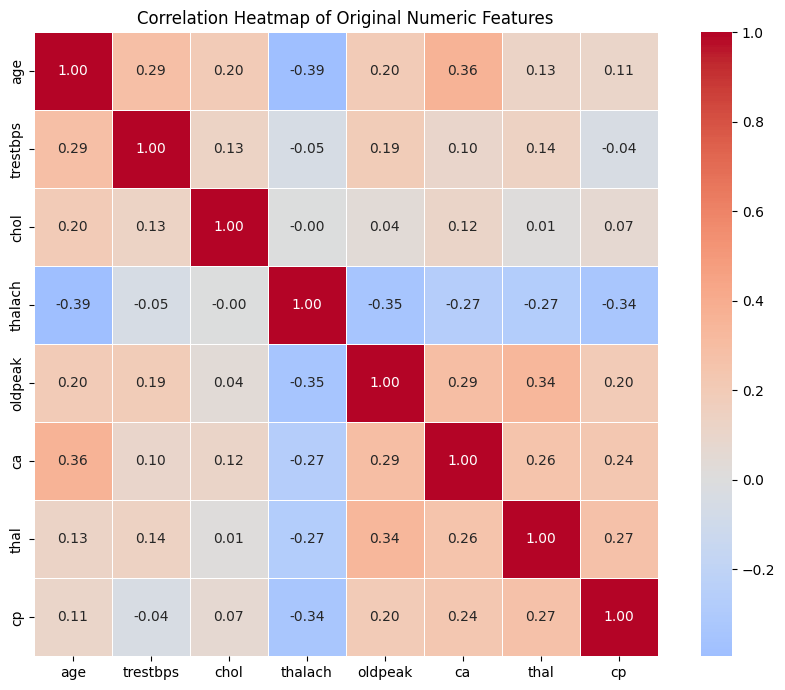

Saved correlation_heatmap.png

Top 3 feature pairs by absolute correlation:
age      thalach    0.394563
         ca         0.362210
thalach  oldpeak    0.347640
dtype: float64


In [26]:
print("Correlation Heatmap")

NUMERIC_FEATURES = ["age", "trestbps", "chol", "thalach", "oldpeak", "ca", "thal", "cp"]
corr = df[NUMERIC_FEATURES].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(
    corr, annot=True, fmt=".2f", cmap="coolwarm",
    center=0, square=True, linewidths=0.5
)

plt.title("Correlation Heatmap of Original Numeric Features")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150)
plt.show()
print("Saved correlation_heatmap.png")

upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
top3  = upper.stack().abs().sort_values(ascending=False).head(3)

print("\nTop 3 feature pairs by absolute correlation:")
print(top3)